# TP4 : Reconnaissance de mots isolés par programmation dynamique (DTW)

BENITAH - GERARD :
Déposer le notebook sur moodle à la fin de la séance.

In [3]:
%pip -q install --upgrade pip
%pip -q install scipy pydub

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# Réutilisation de fonctions pour la lecture et la paramétrisation

`Paramétrisation`

La paramétrisation ou le calcul des paramètres acoustiques à partir du signal de parole, consiste à transformer le signal échantillonné du son brut en paramètres acoustiques, dont le but est d'extraire
l'information pertinente pour la tâche proposée. 

Parmi les paramètres utilisés on peut citer trois catégories principales :

 - les paramètres spectraux : transformée de Fourier, bancs de filtres;
 - les paramètres temporels : le taux de passage par zéro, le débit d'élocution;
 - les paramètres cepstraux : MFCC (Mel Frequency Cepstral Coefficient)

Les paramètres cepstraux sont utilisés pour séparer l'influence de la source d'excitation vocale et celle du
conduit vocal, cette dernière étant généralement la seule à être utilisée dans le domaine de la reconnaissance du locuteur.


Les coefficients cepstraux de fréquence de Mel (MFCC) sont largement utilisés dans la reconnaissance vocale et l'identification des locuteurs. 

 - Les fonctionnalités MFCC sont généralement prétraitées avant d'être utilisées pour la reconnaissance. 
 
 - L'un des prétraitements consiste à créer des coefficients delta et delta-delta et à les apposer à MFCC pour créer un vecteur de caractéristiques. 

 - Un autre prétraitement est la normalisation moyenne des coefficients. 
 
 L'effet de la précision d'un système d'identification peut se baser sur la quantification vectorielle (VQ).        
 De plus, il est démontré que la normalisation de la variance du coefficient, peut améliorer la précision.

In [15]:
# ces deux dict seront utiles par la suite
ref2ind = {"alpha":0, "bravo":1, "charlie":2, "delta":3, "echo":4, "foxtrott":5, "golf":6, "hotel":7, "india":8, "juliett":9, "kilo":10, "lima":11, "mike":12}
ind2ref = {0:"alpha", 1:"bravo", 2:"charlie", 3:"delta", 4:"echo", 5:"foxtrott", 6:"golf", 7:"hotel", 8:"india", 9:"juliett", 10:"kilo", 11:"lima", 12:"mike"}

`Fonction lecture`
  - permet de lire un fichier son et de founir ses caractéristiques (fréquence d’échantillonnage, durée).

In [1]:
import os
cwd = os.getcwd()
path = "M2_IAFA/TP_M2IAFA/TP_M2_SON/TP2/"

In [2]:
import scipy.io.wavfile as wav

TRAIN_PATH = path + '/SIGNAL/OBS/'
sample_rate, audio = wav.read(TRAIN_PATH + "alpha.wav")
print("Sample rate: {0}Hz".format(sample_rate))
print("Audio duration: {0}s".format(len(audio) / sample_rate))

Sample rate: 16000Hz
Audio duration: 0.7919375s


In [3]:
import scipy.io.wavfile as wav

# LECTURE d'un fichier Wave
def lecture(fichier, nb_bits):   
    # Charger un fichier audio
    fs, sig = wav.read(fichier) 
    # Normaliser le signal entre -1 et 1 pour éviter les dépassements dans les calculs
    signal = sig / 2 ** (nb_bits - 1)        
    duree = len(signal) / fs     
    # Durée du signal (en secondes)
    return signal, fs, duree

`Fonction parametrisation`
- Calcule pour un fichier sonore les paramètres acoustiques (coefficients cepstraux) 

  - sur des fenêtres de "taille_fenetre" avec un recouvrement de moitié 
- Les paramètres spectraux : transformée de Fourier, bancs de filtres;

In [4]:
import math
import numpy as np
from math import floor, inf, dist

# Calcul de "nbe_coef" coefficients cepstraux
def parametrisation(signal, taille_fenetre, nbe_coef):    
    # Initialisation de la matrice résultat
    recouvrement = floor(taille_fenetre / 2)
    nb_fen = floor((np.size(signal) - taille_fenetre) / recouvrement) + 1
    mfcc = np.zeros((nb_fen, nbe_coef))    
    # Calcul des MFCC
    for fen in range(nb_fen):
        p = fen * recouvrement
        spectre = abs(np.fft.fft(np.multiply(signal[p:p + taille_fenetre], np.hamming(taille_fenetre))))
        spectre = np.maximum(spectre, 1e-10)
        cepstre = np.fft.fft(np.log(spectre))
        cc = cepstre[1:nbe_coef+1].real
        mfcc[fen, :] = cc
    return mfcc
    

`Nombre de fichiers du répertoire considéré`

In [5]:
import os
def compter_fichiers(chemin):
    return len([f for f in os.listdir(chemin) if os.path.isfile(os.path.join(chemin, f))])

`Paramétrisation totale`      

Ecrire votre fonction "parametrisation_total" (utilisant la fonction "parametrisation")
 - afin qu’elle permette de calculer les paramètres pour l’ensemble des fichiers d’un répertoire
 - "rep_wav" et de stocker les résultats dans un répertoire "rep_mfcc".    
 - Cette fonction renvoie la liste des noms de fichiers traités.

In [6]:
import os
import numpy as np
# Fonction de paramétrisation totale --> tous les fichiers du répertoire 'WAV/APP'
def parametrisation_total(nb_bits, taille_fenetre, nbe_coef, rep_wav, rep_mfcc):
      # Liste des fichiers traités
    source_directory = rep_wav
    destination_directory = rep_wav + '/' + rep_mfcc + '/'
    if not (os.path.exists(destination_directory) and os.path.isdir(destination_directory)):
       os.makedirs(destination_directory, exist_ok=False)

    for file in os.listdir(source_directory):
        res = os.path.join(source_directory, file)
        if os.path.isfile(res):         
           signal, _, _ = lecture(res, nb_bits)
           mfcc = parametrisation(signal, taille_fenetre, nbe_coef)
           # Sauvegarder les coefficients MFCC dans un fichier CSV
           mfcc_res_location = destination_directory + 'mfcc_'+ os.path.splitext(os.path.basename(file))[0] + '.csv'
           np.savetxt(mfcc_res_location, mfcc, delimiter=',')
           #print(f'2 : {mfcc_res_location}')


# Programmation dynamique

`Ecrire une fonction "dtw" Dynamic Time Warping qui prend deux arguments en entrée` :
 - la matrice de coefficients cepstraux du signal à reconnaître (observation) 
 - la matrice de coefficients cepstraux d'un signal de référence. 

Cette fonction renvoie le coût normalisé.

`Phase d'apprentissage`
- chaque mot est modélisé par une réalisation (référence)
- Chaque mot est une référence qui constitue le dictionnaire des modèles

`Phase de reconnaissance`
- Calcule d'une distance de l'observation aux références.
- Le mot reconnu est celui dont la distance esrt la plus proche de l'observation.
   - Recherche de la référence $R_m$ la plus proche de l'image acoustique du mot $M$ à l'aide d'une distance $D$.
   - La distance utilisée dépend de la nature des paramètres (alignement temporel).



:::

for $i = 1$ to $N$ .   
&nbsp;&nbsp;&nbsp; for $j = 1$ to $N$ .  
&nbsp;&nbsp;&nbsp;&nbsp; $D_{i,j}$ = dist($x_i,y_j$) + min $\Biggl\{ 
       \begin{aligned}
          D_{i-1,j-1} \text{ (match)} \\
          D_{i-1,j} \text{  (insertion)} \\
          D_{i,j-1} \text{ (deletion)} \\
    \end{aligned} 
    $
:::
    

   

In [7]:
def dist_euclid(a, b):
    return np.sqrt(np.sum((np.array(a) - np.array(b))**2))

In [8]:
# Calcul de la DTW entre deux vecteurs
def dtw(mfcc_ref, mfcc_obs):   

    mfcc_ref = np.loadtxt(mfcc_ref, delimiter=',')
    mfcc_obs = np.loadtxt(mfcc_obs, delimiter=',')

    ligne, colonne = len(mfcc_ref), len(mfcc_obs)
    matrice_distance = np.zeros((ligne, colonne),dtype=np.float64)

    for i in range(ligne):
        for j in range(colonne):
            matrice_distance[i, j] = dist_euclid(mfcc_ref[i], mfcc_obs[j])

    n, m = matrice_distance.shape
    cout_cumule = np.zeros((n, m))
    cout_cumule[0, 0] = matrice_distance[0, 0]

    for i in range(1, n):
        cout_cumule[i, 0] = cout_cumule[i-1, 0] + matrice_distance[i, 0]

    for j in range(1, m):
        cout_cumule[0, j] = cout_cumule[0, j-1] + matrice_distance[0, j]

    for i in range(1, n):
        for j in range(1, m):
            cout_cumule[i, j] =  min(
                                    (cout_cumule[i-1, j]   + matrice_distance[i, j]),
                                    (cout_cumule[i-1, j-1] + matrice_distance[i, j]),
                                    (cout_cumule[i, j-1])
                                    )
    # Calcul du coût normalisé
    longueur_chemin = n + m - 1  # Approximation de la longueur du chemin optimal
    cout_normalise = cout_cumule[-1, -1] / longueur_chemin
    return cout_normalise
              
    

`Fonction dtw_total`        

S'appuyant sur dtw la fonction calcule le DTW sur  :
   - toutes les observations (fichiers Wave) du répertoire "rep_obs" par rapport à 
   - toutes les références (fichiers MFCC) du répertoire "rep_ref" .      

Cette fonction renvoie une matrice de coûts de taille nb_fichier_obs x nb_fichier_ref.

In [9]:
# DTW sur toutes les observations par rapport à toutes les références
def DTW_total(nb_bits, taille_fenetre, nbe_coef, rep_wave_ref, rep_mfcc, rep_wave_obs):
     
    ligne = compter_fichiers(rep_wave_ref+'/'+rep_mfcc)
    colonne = compter_fichiers(rep_wave_obs+'/'+rep_mfcc)

    cost = np.zeros((ligne, colonne),dtype=np.float64)     
    for i, ref in enumerate(os.listdir(rep_wave_ref+'/'+rep_mfcc)):
        for j, obs in enumerate(os.listdir(rep_wave_obs+'/'+rep_mfcc)):
            rp_mfcc_ref = rep_wave_ref+'/'+rep_mfcc+'/'+ref
            rp_mfcc_obs = rep_wave_obs+'/'+rep_mfcc+'/'+obs
            cost[i,j] = dtw(rp_mfcc_ref, rp_mfcc_obs)
    return cost

#### Affichages et tests

 - Ecrire un programme principal qui lance les fonctions précédentes 
 - Il affiche pour chaque observation (mot inconnu), le mot le plus probable.

`Le processus, appelé backtracking` 

Le backtracking ou "retour sur trace", est une étape cruciale de l'algorithme Dynamic Time Warping (DTW) qui permet de trouver le chemin d'alignement optimal entre deux séquences temporelles. 

`Voici comment cela fonctionne `

On commence à la dernière cellule de la matrice de coût cumulé, qui représente le coût total de l'alignement des deux séquences complètes.

 - À partir de cette cellule, on examine les trois cellules voisines : 
    - celle directement au-dessus, 
    - celle à gauche, 
    - celle en diagonale en haut à gauche.

 - On choisit la cellule avec le coût minimal parmi ces trois options.
 - On répète ce processus, en se déplaçant toujours vers la cellule de coût minimal, jusqu'à atteindre la première cellule de la matrice (en haut à gauche).

Le chemin ainsi tracé représente l'alignement optimal entre les deux séquences, en tenant compte des variations temporelles.

Ce processus permet de déterminer comment les trames des deux séquences (par exemple, les vecteurs MFCC de deux mots prononcés) s'alignent le mieux, en minimisant la distance totale entre elles. 

C'est particulièrement utile dans la reconnaissance de la parole pour gérer les différences de vitesse d'élocution entre les mots de référence et les mots observés.

In [10]:
# Initialisation
nb_bits = 16
taille_fenetre = 1024
nbe_coef = 16
rep_wave_ref = path + 'SIGNAL/REF'
rep_wave_obs = path + 'SIGNAL/OBS'
rep_mfcc = 'MFCC'

def main_prgm (nb_bits=16, taille_fenetre=1024, nbe_coef = 16, 
               rep_wave_ref=rep_wave_ref, rep_wave_obs=rep_wave_obs, rep_mfcc='MFCC'):
    # Paramétrisation des fichiers
    parametrisation_total(nb_bits, taille_fenetre, nbe_coef, rep_wave_ref, rep_mfcc) 
    parametrisation_total(nb_bits, taille_fenetre, nbe_coef, rep_wave_obs, rep_mfcc) 

    cost_matrix = DTW_total(nb_bits, taille_fenetre, nbe_coef, rep_wave_ref, rep_mfcc, rep_wave_obs)

    n = cost_matrix.shape[0] - 1
    m = cost_matrix.shape[0] - 1

    sum_cost = sum(cost_matrix) 

    val = [0, 0, 0]
    path= []

    while  n  > 0 or m  > 0 :        
        if n == 0 or m == 0 :
           break
        # n : reférence 
        # m : observation
        score = 1 - (cost_matrix[n,m] / sum_cost[n])
        
        cost  = cost_matrix[n,m]
        refr  = ind2ref[m]
        obvs  = ind2ref[n]
        
        path.append((cost,obvs,refr,score))

        val[0] = cost_matrix[n-1, m]   # gauche
        val[1] = cost_matrix[n-1, m-1] # diagonale
        val[2] = cost_matrix[n, m-1]   # haut

        pos = np.argmin(val)

        if   pos == 0 : n -= 1 
        elif pos == 2 : m -= 1
        elif pos == 1 :   
             n -= 1 
             m -= 1  

    #for tupl in path:
     #   print(f'coût : {tupl[0]} observation : {tupl[1]}, mot le plus probable : {tupl[2]}, score : {tupl[3]} ')
    return  path  
        


`Affichage amélioré`

 - Ajouter, un affichage des coûts entre une observation et chaque référence sous forme d'histogramme.
 - Calculer le score de reconnaissance.
 - Pour chaque observation, affichage des coûts (par rapport aux références) sous forme d'histogramme.

In [12]:
import matplotlib.pyplot as plt

def afficher_couts_et_score(result):
    couts  = []
    obvser = []
    scores = []
    refers = []
    #print(f'result: {type(result)} {result}')
    for cout, ref, obs, score in result:
        couts.append(cout)
        obvser.append(obs)
        scores.append(score)
        refers.append(ref)
    
    # Créer l'histogramme
    plt.figure(figsize=(8, 3))
    bars = plt.bar(obvser, couts)
    plt.title("Coûts DTW entre les références et les observations")
    plt.xlabel("Mots observés")
    plt.ylabel("Coût DTW")
    plt.xticks(rotation=45)
    
    # Ajouter les références et les scores sur les barres
    for i, bar in enumerate(bars):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height/2,
                 f'Ref: {refers[i]}\nScore: {scores[i]:.2f}',
                 ha='center', va='center', rotation='vertical')
    
    plt.tight_layout()
    plt.show()

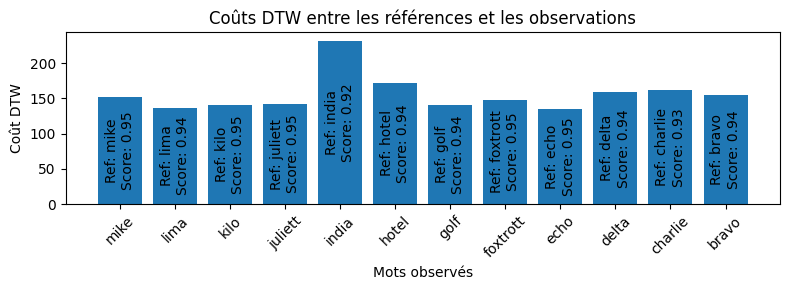

In [16]:
result = main_prgm()
afficher_couts_et_score(result)

`Autres tests`   
     
Tester sur vos propres enregistrements et modifier :
- le nombre de paramètres (coefficients cepstraux)
- la taille de la fenêtre d’analyse


In [17]:
from pydub import AudioSegment
import os
# Répertoire source contenant les fichiers m4a

source = path + 'SIGNAL/PER/'
destin = path + 'SIGNAL/TES/'
for f in os.listdir(source) : 
    # Charger le fichier m4a
    audio = AudioSegment.from_file(source+f, format="m4a")
    # Exporter en format wav
    name  = destin + os.path.splitext(os.path.basename(f))[0] + ".wav"
    audio.export(name, format="wav")

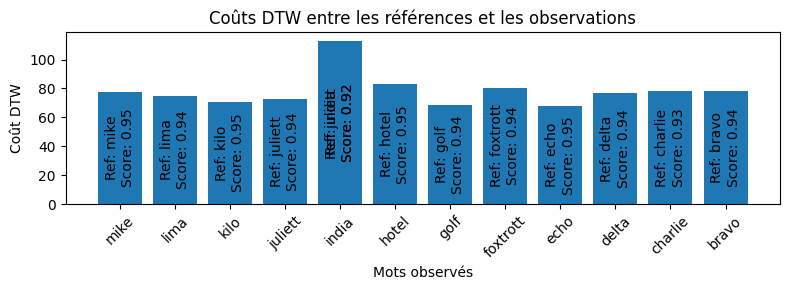

In [20]:
result = main_prgm(nb_bits=16, taille_fenetre=512, nbe_coef=16, 
                   rep_wave_ref=rep_wave_ref, rep_wave_obs=rep_wave_obs, rep_mfcc='MFCC')
afficher_couts_et_score(result)